Obtain elk data from [iNaturalist](https://www.inaturalist.org/) [API](https://github.com/pyinat/pyinaturalist) and [LILA-BC](https://lila.science/datasets) [API](https://huggingface.co/datasets/society-ethics/lila_camera_traps). INaturalist allows enthusiasts to take pictures while they are in nature (e.g. on a hike) and upload them to a platform where experts can curate the species data to ensure quality. LILA-BC on the other hand brings together camera trap datasets from installments around the world. At the moment, we only show data from "Idaho Camera Traps" but if needed, see this [page](https://huggingface.co/datasets/society-ethics/lila_camera_traps) for more camera trap locations. Adapted from this notebook: https://colab.research.google.com/drive/1wdj996_T-JlLAVi18m07S4BtjT1-EYXu?usp=sharing#scrollTo=G3SlNj19UbDi

In [1]:
from pyinaturalist import get_observations, Observation
from pyinaturalist.formatters import pprint

In [2]:
# https://github.com/pyinat/pyinaturalist/blob/main/examples/Tutorial_1_Observations.ipynb [9]
response = get_observations(taxon_name='Cervus canadensis')

In [3]:
response['total_results']

50191

In [4]:
pprint(response)

 ID          Taxon ID   Taxon                       Observed on    User                 Location                  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  322715890   204114     Cervus canadensis           Oct 22, 2025   napoleon1799         Rocky Mountain National   
                         (Wapiti)                                                        Park, Estes Park, CO, US  
  322715657   204114     Cervus canadensis           Oct 22, 2025   napoleon1799         Rocky Mountain National   
                         (Wapiti)                                                        Park, Estes Park, CO, US  
  322713953   204114     Cervus canadensis           Oct 21, 2025   napoleon1799         Rocky Mountain National   
                         (Wapiti)                                                        Park, Estes Park, CO, US  
  322678642   566550     Cervus canadensis           Oct 23, 2025   seabeck              Washington, US            
                         roosevelti (Roosevelt                                                                     
                         Elk)                                                                                      
  322674195   204114     Cervus canadensis           Sep 17, 2025   mineralmissy         Bear Lake-Glacier Gorge   
                         (Wapiti)                                                        Junction-Loch Mills       
                                                                                         Junction Trail, Estes     
                                                                                         Park, CO, US              
  322673715   564777     Cervus canadensis           Aug 13, 2025   rangermicah          Payson, AZ 85541, USA     
                         canadensis (American Elk)                                                                 
  322670863   204114     Cervus canadensis           Aug 10, 2024   alex_barone          Dream Lake-Lake Haiyaha   
                         (Wapiti)                                                        Trail, Estes Park, CO,    
                                                                                         US                        
  322661259   204114     Cervus canadensis           Oct 23, 2025   jennypansing         North Carolina, US        
                         (Wapiti)                                                                                  
  322660966   204114     Cervus canadensis           Oct 23, 2025   jennypansing         North Carolina, US        
                         (Wapiti)                                                                                  
  322660899   204114     Cervus canadensis           Oct 23, 2025   jennypansing         North Carolina, US        
                         (Wapiti)                                                                                  
  322660826   204114     Cervus canadensis           Oct 23, 2025   jennypansing         North Carolina, US        
                         (Wapiti)                                                                                  
  322654647   204114     Cervus canadensis           Oct 22, 2025   eliloftis            Okanogan County, WA, USA  
                         (Wapiti)                                                                                  
  322654515   566549     Cervus canadensis           Oct 22, 2025   betweenthelyons      Colusa County, CA, USA    
                         nannodes (Tule Elk)                                                                       
  322635149   564777     Cervus canadensis           Oct 23, 2025   birdwhisperer        Ashton, ID 83420, USA     
                         canadensis (American Elk)                                                                 
  322615991   566550     Cervus canadensis           Jul 

In [5]:
observations = Observation.from_json_list(response)
observations[0].photos[0]


Photo(
    id=583853245,
    attribution='(c) napoleon1799, all rights reserved',
    original_dimensions=(2048, 1536),
    url='https://static.inaturalist.org/photos/583853245/square.jpg'
)

In [6]:
from PIL import Image
import requests
from io import BytesIO

def fetch_inat_img(obs):
  try:
    # by default the square image returned is too small. switch to `original` or `large`
    response = requests.get(obs.url.replace('square.jpg', 'original.jpg'))
    img = Image.open(BytesIO(response.content)).resize((256, 256))
    return img
  except:
    print("Error while loading image.")
    return None

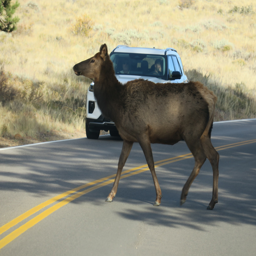

In [7]:
fetch_inat_img(observations[0].photos[0])

In [8]:
# LILA-BC # https://huggingface.co/datasets/society-ethics/lila_camera_traps
from datasets import load_dataset
dataset = load_dataset("society-ethics/lila_camera_traps", "Idaho Camera Traps", split="train", trust_remote_code=True)
taxonomy = dataset.features["annotations"].feature["taxonomy"] # type: ignore

/Users/alex/Desktop/CS/ML/YADES/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
elks = dataset.filter(lambda x: x["annotations"]["taxonomy"][0]["species"] == taxonomy["species"].str2int("cervus canadensis"))

In [10]:
print(f"Full dataset: {dataset.shape}")
print(f"Only elks: {elks.shape}")

Full dataset: (1513530, 8)
Only elks: (135711, 8)


In [11]:
# The current links in the LILA dataset are broken :( so we need to redirect them to the
# currently live link in googleapis storage
def fix_image_url(old_url):
    if old_url.startswith("https://lilablobssc.blob.core.windows.net/"):
        new_prefix = "https://storage.googleapis.com/public-datasets-lila/"
        return new_prefix + old_url.split("lilablobssc.blob.core.windows.net/")[-1]
    return old_url

def fix_dataset_images(dataset):
  return dataset.map(lambda x: {"image": fix_image_url(x["image"])})

elks = fix_dataset_images(elks)

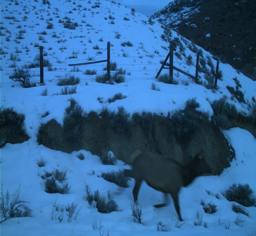

In [12]:
def fetch_lila_img(obs):
  try:
    response = requests.get(obs['image'])
    img = Image.open(BytesIO(response.content)).resize((256, 256))
    img = img.crop((0, 8, 256, 244)) # have to crop out camera annotations
    return img
  except:
    print("Error while loading image.")
    return None
fetch_lila_img(elks[0])

In [13]:
# load animal detection model so we can filter out images without elk
import sys
sys.path.append("..")
from scripts.yolo_quantprune import YOLOQuantPrune
import cv2
import torchvision.transforms as transforms
import numpy as np
model = YOLOQuantPrune.load("../data/yolo-finetune/10_epoch_224_imgsz/weights/qat_pruned.pt").eval()
def identify(image: Image.Image):
    np_image = np.array(image)
    cv2_image = cv2.cvtColor(np_image, cv2.COLOR_RGB2BGR)
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Resize((224, 224)),
        ]
    )
    cv2_image = transform(cv2_image)
    cv2_image = cv2_image.unsqueeze(0)  # type: ignore
    return model.predict(cv2_image)

/Users/alex/Desktop/CS/ML/YADES/venv/lib/python3.10/site-packages/torch/_utils.py:392: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  device=storage.device,


In [14]:
identify(fetch_lila_img(elks[0]))

/Users/alex/Desktop/CS/ML/YADES/notebooks/../scripts/yolo_quantprune.py:117: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/quantized/cpu/TensorShape.cpp:168.)
  return self.cv2(torch.cat(y, 1))


'animal'

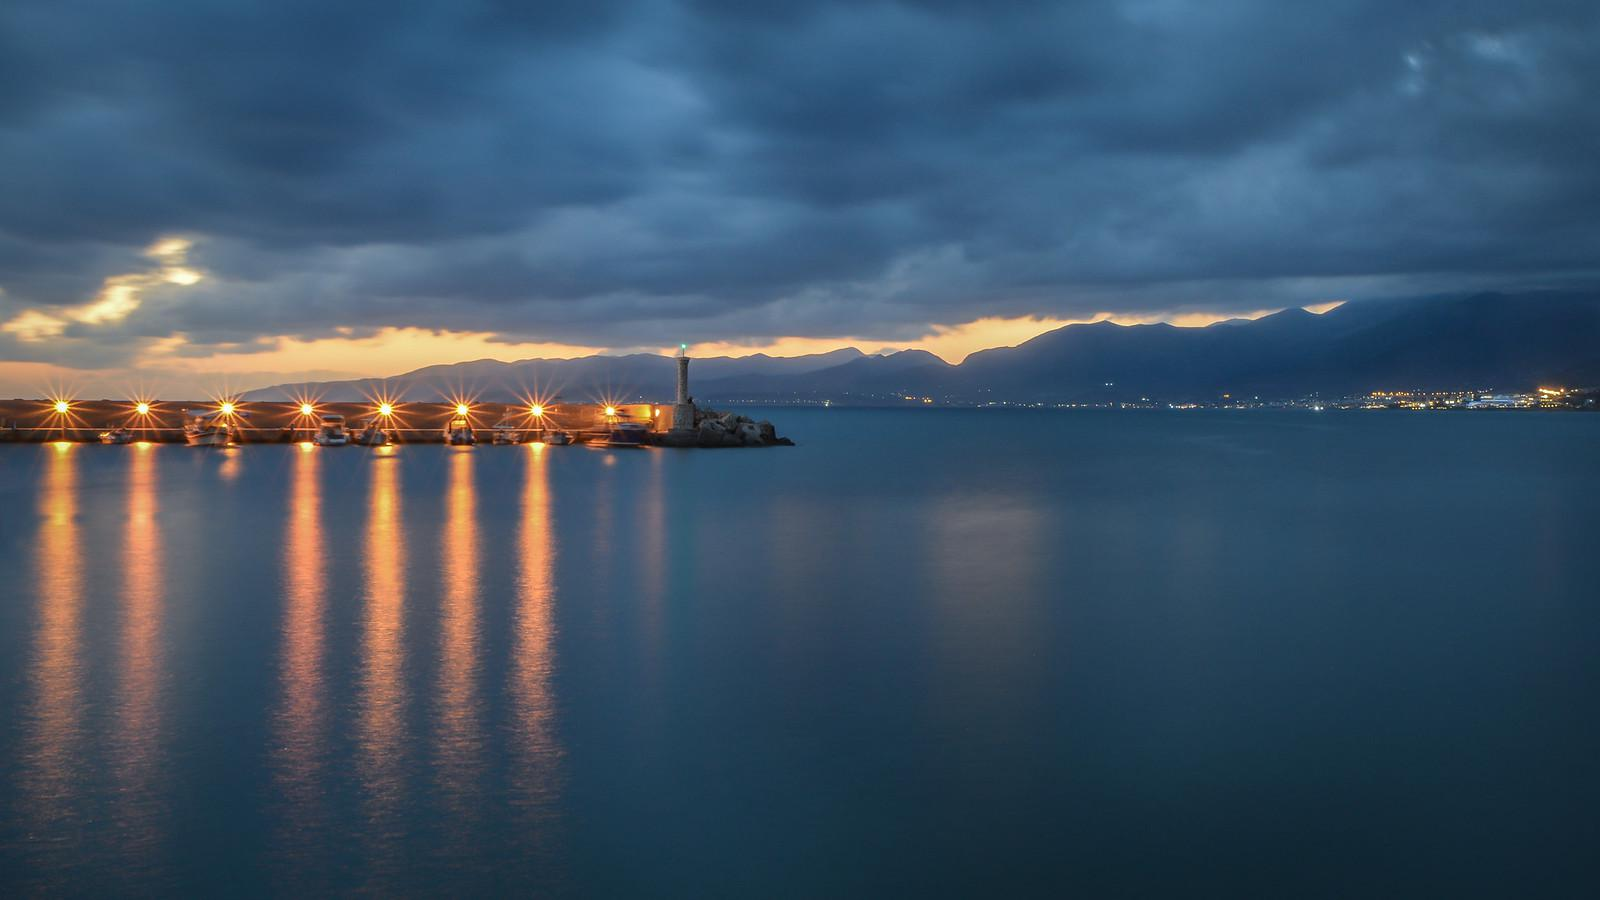

In [15]:
# grab image that is not an elk
import os
animals = os.listdir("../.data/animal/train/animal")
nonanimals = os.listdir("../.data/animal/train/non-animal")
def get_random_non_elk():
    if np.random.rand() > 0.5:
        return Image.open("../.data/animal/train/non-animal/" + np.random.choice(nonanimals))
    else:
        return Image.open("../.data/animal/train/animal/" + np.random.choice(animals))
get_random_non_elk()

In [19]:
# extract and format in yolo format:
# YOLO_DATA_PATH/
#  |--- train/
#  |     |--- elk/
#  |     |--- non-elk/
#  |--- val/
#  |     |--- elk/
#  |     |--- non-elk/
#  |--- test/
#  |     |--- elk/
#  |     |--- non-elk/
YOLO_DATA_PATH = '../.data/elk'
NUM_TRAIN = 8_000
NUM_VAL = 2_000
NUM_TEST = 2_000

def gen_split(split, num, start=0):
    try:
        os.mkdir(YOLO_DATA_PATH)
    except:
        pass
    try:
        os.mkdir(os.path.join(YOLO_DATA_PATH, split))
    except:
        pass
    try:
        os.mkdir(os.path.join(YOLO_DATA_PATH, split, "elk"))
    except:
        pass
    try:
        os.mkdir(os.path.join(YOLO_DATA_PATH, split, "other"))
    except:
        pass
    for i in range(start, num):
        if i % 2 == 0:
            # if i % 4 == 0:
            #     while True:
            #         img = fetch_inat_img(next(inat_iter).photos[0])
            #         if img and identify(img) == "animal":
            #             img.save(os.path.join(YOLO_DATA_PATH, split, "elk", f"{i}.png"))
            #             break
            # else:
            while True:
                img = fetch_lila_img(elks[np.random.randint(0, len(elks))]) # type: ignore
                if img and identify(img) == "animal":
                    img.save(os.path.join(YOLO_DATA_PATH, split, "elk", f"{i}.png"))
                    break
        else:    
            get_random_non_elk().save(os.path.join(YOLO_DATA_PATH, split, "other", f"{i}.png"))

gen_split("train", NUM_TRAIN)
gen_split("val", NUM_VAL)
gen_split("test", NUM_TEST)

/Users/alex/Desktop/CS/ML/YADES/notebooks/../scripts/yolo_quantprune.py:117: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/quantized/cpu/TensorShape.cpp:168.)
  return self.cv2(torch.cat(y, 1))


In [20]:
with open(os.path.join(YOLO_DATA_PATH, "data.yaml"), "w") as f:
    f.write("""
path: ../.data/elk  # dataset root path
train: train  # train images (relative to 'path')
val: val  # val images (relative to 'path')
test: test # test images (relative to 'path')

# Classes
names:
  0: elk
  1: other
""".strip())